In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from linear_regression_scratch import *

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

## Step 1 - EDA

In [2]:
housing = fetch_california_housing()

In [3]:
housing.data.shape, housing.target.shape

((20640, 8), (20640,))

In [4]:
housing["feature_names"]

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [5]:
housing["target"]

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [6]:
df = pd.DataFrame(data = housing["data"], columns = housing["feature_names"])
df["target"] = housing["target"]

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
df.shape

(20640, 9)

In [8]:
df.dtypes

MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
target        float64
dtype: object

In [9]:
df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

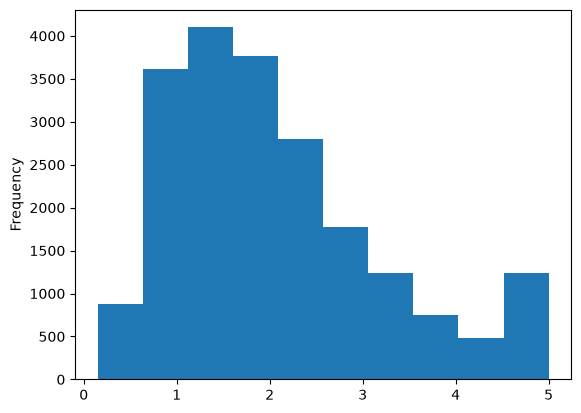

In [10]:
df["target"].plot.hist();

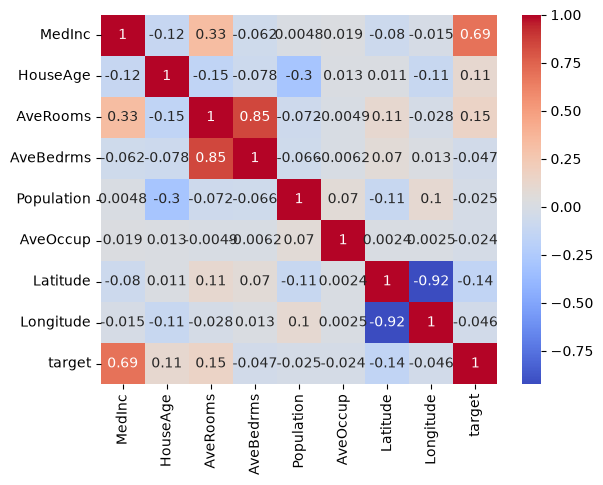

In [11]:
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.show()

## Step 2 — Preprocessing

In [12]:
np.random.seed(42)

X = df.drop("target", axis = 1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

X_train.shape, X_test.shape

((16512, 8), (4128, 8))

In [13]:
standard_scaler = StandardScaler()
X_train_scaled = standard_scaler.fit_transform(X_train)

In [14]:
X_train_scaled[0]

array([-0.326196  ,  0.34849025, -0.17491646, -0.20836543,  0.76827628,
        0.05137609, -1.3728112 ,  1.27258656])

## Step 3 — Linear Regression from scratch

In [15]:
y_train = y_train.to_numpy().reshape(-1, 1)
y_test = y_test.to_numpy().reshape(-1, 1)

In [16]:
y_train

array([[1.03 ],
       [3.821],
       [1.726],
       ...,
       [2.221],
       [2.835],
       [3.25 ]], shape=(16512, 1))

In [17]:
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_scaled = standard_scaler.transform(X_test)
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

In [18]:
X_train_b[0]

array([ 1.        , -0.326196  ,  0.34849025, -0.17491646, -0.20836543,
        0.76827628,  0.05137609, -1.3728112 ,  1.27258656])

In [19]:
w = np.zeros((X_train_b.shape[1], 1))
w

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [20]:
w, cost_history = gradient_descent(X_train_b, y_train, w, learning_rate = 0.01, iterations = 1000)

In [21]:
w

array([[ 2.07185749],
       [ 0.82894365],
       [ 0.17853146],
       [-0.13794939],
       [ 0.15669182],
       [ 0.01681517],
       [-0.04522857],
       [-0.48705563],
       [-0.45147126]])

In [22]:
cost_history[:5], cost_history[-5:]

([np.float64(2.7649865663007085),
  np.float64(2.7161064810518427),
  np.float64(2.6682104073522517),
  np.float64(2.6212782731052235),
  np.float64(2.575290423418236)],
 [np.float64(0.27393073727859074),
  np.float64(0.27390777072360334),
  np.float64(0.27388484047885453),
  np.float64(0.2738619464857222),
  np.float64(0.2738390886856819)])

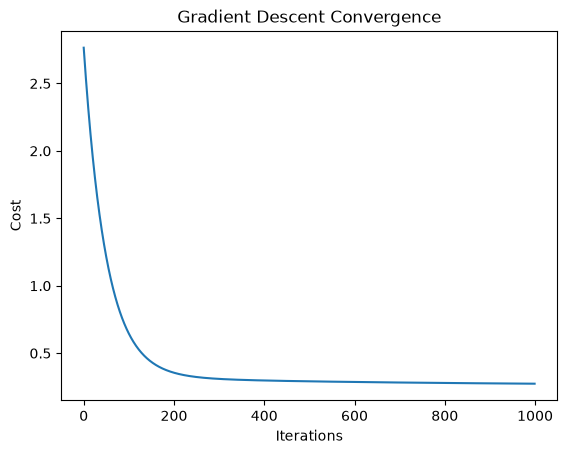

In [23]:
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")
plt.savefig("assets/gradient-descent-convergence.png")
plt.show()

In [24]:
y_pred_numpy = hypothesis(X_test_b, w)
numpy_mse = np.mean((y_pred_numpy - y_test) ** 2)

print(f"Test MSE: {numpy_mse}")

Test MSE: 0.567185298608222


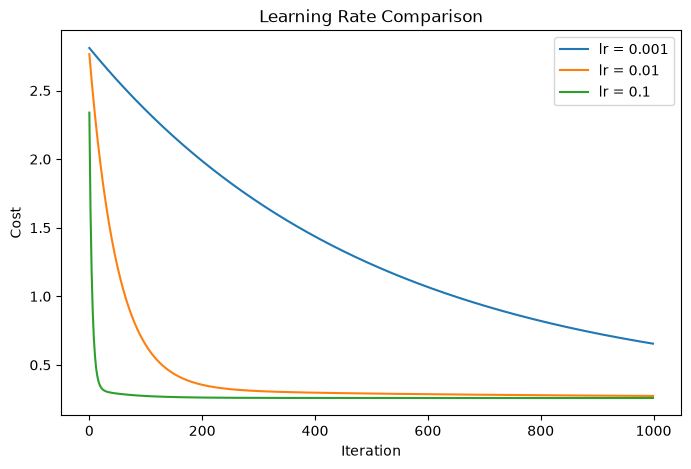

In [25]:
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize = (8, 5))

for lr in learning_rates:

    w_test = np.zeros((X_train_b.shape[1], 1))
    _, costs = gradient_descent(X_train_b, y_train, w_test, learning_rate = lr, iterations = 1000)
    plt.plot(costs, label=f"lr = {lr}")

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Learning Rate Comparison")
plt.legend()
plt.savefig("assets/learning-rate-comparison.png")
plt.show()

## Step 4 — Scikit-learn implementation

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [27]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 8)","[[ 0.85, 0.12,-0.29,...,-0.04,-0.9 ,-0.87]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[2.07]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[182.86,175.83,145. ,...,104.18, 36.96, 27.94]"


In [28]:
y_preds = lr.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_preds)
r2 = r2_score(y_test, y_preds)

print(f"Test MSE: {mse:.4f}")
print(f"Test R^2: {r2:.4f}")

Test MSE: 0.5559
Test R^2: 0.5758


In [29]:
print(f"NumPy MSE : {numpy_mse:.4f}")
print(f"sklearn MSE: {mse:.4f}")
print(f"Difference: {(numpy_mse - mse):.4f}")

NumPy MSE : 0.5672
sklearn MSE: 0.5559
Difference: 0.0113


## Step 5 — Validate from-scratch against sklearn

In [30]:
numpy_intercept = w[0, 0]
numpy_coefficients = w[1:, 0]

sklearn_intercept = lr.intercept_[0] if lr.intercept_.ndim > 0 else lr.intercept_
sklearn_coefficients = lr.coef_.ravel()

print("Intercept Comparison")
print(f"NumPy : {numpy_intercept:.6f}")
print(f"sklearn : {sklearn_intercept:.6f}")

print("\nCoefficient Comparison")

for i, (nw, sw) in enumerate(zip(numpy_coefficients, sklearn_coefficients)):
    print(f"Feature {i + 1}: NumPy = {nw:.6f}, sklearn = {sw:.6f}, Difference = {abs(nw-sw):.6e}")

Intercept Comparison
NumPy : 2.071857
sklearn : 2.071947

Coefficient Comparison
Feature 1: NumPy = 0.828944, sklearn = 0.854383, Difference = 2.543938e-02
Feature 2: NumPy = 0.178531, sklearn = 0.122546, Difference = 5.598522e-02
Feature 3: NumPy = -0.137949, sklearn = -0.294410, Difference = 1.564607e-01
Feature 4: NumPy = 0.156692, sklearn = 0.339259, Difference = 1.825677e-01
Feature 5: NumPy = 0.016815, sklearn = -0.002308, Difference = 1.912290e-02
Feature 6: NumPy = -0.045229, sklearn = -0.040829, Difference = 4.399466e-03
Feature 7: NumPy = -0.487056, sklearn = -0.896929, Difference = 4.098732e-01
Feature 8: NumPy = -0.451471, sklearn = -0.869842, Difference = 4.183705e-01


## Step 6 — Evaluation & diagnostics

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [32]:
y_pred_numpy = hypothesis(X_test_b, w)

numpy_r2 = r2_score(y_test, y_pred_numpy)
numpy_mae = mean_absolute_error(y_test, y_pred_numpy)
numpy_rmse = np.sqrt(mean_squared_error(y_test, y_pred_numpy))

In [33]:
y_pred_sklearn = lr.predict(X_test_scaled)

sklearn_r2 = r2_score(y_test, y_pred_sklearn)
sklearn_mae = mean_absolute_error(y_test, y_pred_sklearn)
sklearn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_sklearn))

In [34]:
print("NumPy Implementation")
print(f"R^2  : {numpy_r2:.4f}")
print(f"MAE  : {numpy_mae:.4f}")
print(f"RMSE : {numpy_rmse:.4f}")

print("\nScikit-learn Implementation")
print(f"R^2  : {sklearn_r2:.4f}")
print(f"MAE  : {sklearn_mae:.4f}")
print(f"RMSE : {sklearn_rmse:.4f}")

NumPy Implementation
R^2  : 0.5672
MAE  : 0.5477
RMSE : 0.7531

Scikit-learn Implementation
R^2  : 0.5758
MAE  : 0.5332
RMSE : 0.7456


In [35]:
results = pd.DataFrame({
    "Model": ["NumPy", "Scikit-learn"],
    "R²": [numpy_r2, sklearn_r2],
    "MAE": [numpy_mae, sklearn_mae],
    "RMSE": [numpy_rmse, sklearn_rmse]
})

results

,Model,R²,MAE,RMSE
0,NumPy,0.567169,0.547676,0.753117
1,Scikit-learn,0.575788,0.533200,0.745581


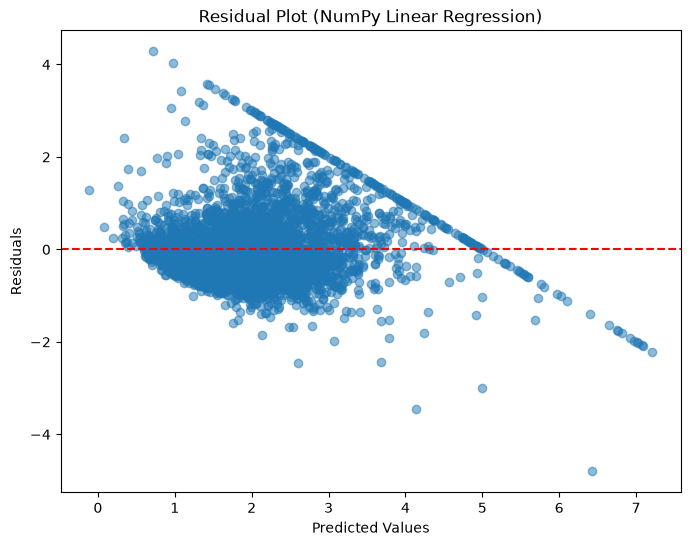

In [36]:
residuals = y_test.flatten() - y_pred_numpy.flatten()

plt.figure(figsize = (8,6))
plt.scatter(y_pred_numpy, residuals, alpha = 0.5)

plt.axhline(y = 0, color = "red", linestyle = "--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (NumPy Linear Regression)")
plt.savefig("assets/residual-plot.png")
plt.show()

The residuals are centered around zero, indicating no strong overall prediction bias. However, they are not randomly scattered and show a fan-shaped pattern, suggesting some heteroscedasticity. A few outliers are also present, indicating larger prediction errors for some houses. Overall, the linear regression model captures the general trend but does not fully explain all variation in the data.